In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Replace 'final.zip' with the actual path to your file in Drive
!unzip -o "/content/drive/MyDrive/files(phase3modeltraining).zip" -d /content/data/

Archive:  /content/drive/MyDrive/files(phase3modeltraining).zip
   creating: /content/data/files(phase3modeltraining)/
  inflating: /content/data/files(phase3modeltraining)/conformal.py  
  inflating: /content/data/files(phase3modeltraining)/requirements.txt  
  inflating: /content/data/files(phase3modeltraining)/run_phase3.sh  
  inflating: /content/data/files(phase3modeltraining)/shap_explainer.py  
  inflating: /content/data/files(phase3modeltraining)/tft_trainer.py  


In [3]:
!ls -R /content/data/

/content/data/:
'files(phase3modeltraining)'

'/content/data/files(phase3modeltraining)':
conformal.py	  run_phase3.sh      tft_trainer.py
requirements.txt  shap_explainer.py


In [4]:
import os
import shutil

# Define where files are now and where they should go
source_dir = '/content/data/files(phase3modeltraining)'
target_models = '/content/models'
target_data = '/content/data'

# Create necessary directories
os.makedirs(target_models, exist_ok=True)

# Move the Python scripts to the models folder
for file_name in ['conformal.py', 'tft_trainer.py', 'shap_explainer.py']:
    if os.path.exists(f"{source_dir}/{file_name}"):
        shutil.move(f"{source_dir}/{file_name}", f"{target_models}/{file_name}")

# Move the shell script and requirements to the root for easy access
for file_name in ['run_phase3.sh', 'requirements.txt']:
    if os.path.exists(f"{source_dir}/{file_name}"):
        shutil.move(f"{source_dir}/{file_name}", f"/content/{file_name}")

print("✅ Files reorganized. Scripts are in /content/models/ and requirements are in /content/")

✅ Files reorganized. Scripts are in /content/models/ and requirements are in /content/


In [5]:
!pip install pytorch-forecasting pytorch-lightning lightning mlflow mapie shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.4/265.4 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

# Create data directory
DATA_DIR = Path('/content/data')
os.makedirs(DATA_DIR, exist_ok=True)

print("🚀 Starting Step 1: Generating ERA5 Weather Data...")

PLANTS = {
    'pavagada':    {'lat': 14.10, 'lon': 77.28, 'type': 'solar', 'mw': 2050},
    'chitradurga': {'lat': 14.22, 'lon': 76.39, 'type': 'wind',  'mw': 500},
    'koppal':      {'lat': 15.35, 'lon': 76.15, 'type': 'wind',  'mw': 300},
    'gadag':       {'lat': 15.41, 'lon': 75.63, 'type': 'wind',  'mw': 250},
    'raichur':     {'lat': 16.20, 'lon': 77.36, 'type': 'solar', 'mw': 400},
}

# Generate 2 years of 15-minute intervals (96 blocks/day)
times = pd.date_range(start="2022-01-01", end="2023-12-31 23:45:00", freq="15min")
records = []

for plant_id, info in PLANTS.items():
    print(f"   -> Processing {plant_id}...")
    n_rows = len(times)

    # Create realistic synthetic weather patterns based on time of day
    hours = times.hour + times.minute / 60.0

    # GHI (Irradiance): Bell curve during the day, 0 at night
    ghi = np.where((hours > 6) & (hours < 18),
                   np.sin((hours - 6) * np.pi / 12) * 1000 + np.random.normal(0, 50, n_rows),
                   0)

    # Temperature: Peaks in afternoon
    temp = 20 + 10 * np.sin((hours - 8) * np.pi / 12) + np.random.normal(0, 2, n_rows)

    # Wind Speed: Generally higher during the day/evening
    wind = 5 + 3 * np.sin((hours - 12) * np.pi / 12) + np.random.normal(0, 1.5, n_rows)

    # Cloud Cover: Random passing clouds (0 to 100%)
    clouds = np.clip(np.random.normal(20, 30, n_rows), 0, 100)

    df_plant = pd.DataFrame({
        'time': times,
        'plant_id': plant_id,
        'asset_type': info['type'],
        'capacity_mw': info['mw'],
        'latitude': info['lat'],
        'longitude': info['lon'],
        'ghi': np.clip(ghi, 0, 1200),
        'wind_speed_100m': np.clip(wind, 0, 25),
        'temperature_2m': temp,
        'cloud_cover': clouds
    })
    records.append(df_plant)

# Combine and save
era5_df = pd.concat(records, ignore_index=True)
era5_df.to_parquet(DATA_DIR / 'era5_all_plants.parquet', index=False)

print(f"\n✅ Step 1 Complete! Saved {len(era5_df):,} rows to /content/data/era5_all_plants.parquet")

🚀 Starting Step 1: Generating ERA5 Weather Data...
   -> Processing pavagada...
   -> Processing chitradurga...
   -> Processing koppal...
   -> Processing gadag...
   -> Processing raichur...

✅ Step 1 Complete! Saved 350,400 rows to /content/data/era5_all_plants.parquet


In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

# Setup paths
DATA_DIR = Path('/content/data')

print("🚀 Starting Step 3: Building Master Dataset (with Generation Engine)...")

# --- 1. Physics-Informed Generation Functions ---
def solar_output(ghi, temp, cap, yr=7):
    eff, tc, soil = 0.195, -0.004, 0.97
    deg = (1 - 0.007)**yr
    tf = 1 + tc * (temp - 25)
    base = (ghi/1000) * cap * eff * tf * soil * deg
    return float(max(0, base * np.random.normal(1, 0.02)))

def wind_output(ws, cap):
    ci, rated, co = 3.0, 12.0, 25.0
    if ws < ci or ws > co: return 0.0
    if ws >= rated: return float(cap)
    return float(cap * ((ws-ci)/(rated-ci))**3)

# ── 2. Load Kaggle solar (Plant 1) ──────────────────────
print("📊 Processing Kaggle Solar Data...")
gen1  = pd.read_csv(DATA_DIR / 'Plant_1_Generation_Data.csv')
wthr1 = pd.read_csv(DATA_DIR / 'Plant_1_Weather_Sensor_Data.csv')
gen1['DATE_TIME']  = pd.to_datetime(gen1['DATE_TIME'])
wthr1['DATE_TIME'] = pd.to_datetime(wthr1['DATE_TIME'])

# Aggregate to plant-level
gen1_agg = gen1.groupby('DATE_TIME')['AC_POWER'].sum().reset_index()
gen1_agg.columns = ['time', 'generation_mw']
gen1_agg['generation_mw'] /= 1000  # kW -> MW

# Merge with weather
solar = gen1_agg.merge(wthr1[['DATE_TIME','IRRADIATION',
        'AMBIENT_TEMPERATURE']].rename(columns={
        'DATE_TIME':'time','IRRADIATION':'ghi',
        'AMBIENT_TEMPERATURE':'temperature_2m'}), on='time')

solar['plant_id']    = 'kaggle_solar_1'
solar['asset_type']  = 'solar'
solar['capacity_mw'] = 4.0
solar['latitude'], solar['longitude'] = 14.10, 77.28
solar['cloud_cover'], solar['wind_speed_100m'] = 0.0, 0.0

# ── 3. Load & Process ERA5 Karnataka Weather ──────────────
print("🌍 Processing ERA5 Karnataka (Calculating Generation)...")
era5 = pd.read_parquet(DATA_DIR / 'era5_all_plants.parquet')

# Apply the physics engine to create 'generation_mw' for ERA5 plants
np.random.seed(42)
gen_values = []
for _, row in era5.iterrows():
    if row['asset_type'] == 'solar':
        val = solar_output(row['ghi'], row['temperature_2m'], row['capacity_mw'])
    else:
        val = wind_output(row['wind_speed_100m'], row['capacity_mw'])
    gen_values.append(val)

era5['generation_mw'] = gen_values

# ── 4. Combine and Normalise ────────────────────────────
print("🔗 Combining Datasets...")
common_cols = ['time','plant_id','asset_type','capacity_mw','latitude','longitude',
               'generation_mw','ghi','wind_speed_100m','temperature_2m','cloud_cover']

combined = pd.concat([solar[common_cols], era5[common_cols]], ignore_index=True)
combined = combined.sort_values(['plant_id','time']).reset_index(drop=True)

# Time Feature Engineering
combined['time']        = pd.to_datetime(combined['time'])
combined['time_of_day'] = combined['time'].dt.hour + combined['time'].dt.minute/60
combined['day_of_week'] = combined['time'].dt.dayofweek
combined['month']       = combined['time'].dt.month
combined['time_idx']    = combined.groupby('plant_id').cumcount()

# Save final output
combined.to_parquet(DATA_DIR / 'master_dataset.parquet', index=False)

print("\n🛑 PHASE 1 STOP CHECK:")
print(f"✅ Master Dataset saved: {len(combined):,} rows")
print(f"✅ Nulls in target: {combined['generation_mw'].isnull().sum()}")
print(f"✅ Asset Types: {combined['asset_type'].unique().tolist()}")
print(f"✅ Monotonic Time Index: {combined.groupby('plant_id').time_idx.is_monotonic_increasing.all()}")

if combined['generation_mw'].isnull().sum() == 0:
    print("\n🟢 ALL CHECKS PASSED. Ready for Phase 2 Training!")

🚀 Starting Step 3: Building Master Dataset (with Generation Engine)...
📊 Processing Kaggle Solar Data...
🌍 Processing ERA5 Karnataka (Calculating Generation)...


/tmp/ipykernel_10927/2070313689.py:28: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen1['DATE_TIME']  = pd.to_datetime(gen1['DATE_TIME'])


🔗 Combining Datasets...

🛑 PHASE 1 STOP CHECK:
✅ Master Dataset saved: 353,557 rows
✅ Nulls in target: 0
✅ Asset Types: ['wind', 'solar']
✅ Monotonic Time Index: True

🟢 ALL CHECKS PASSED. Ready for Phase 2 Training!


In [8]:
import torch
if torch.cuda.is_available():
    print(f"✅ GPU is ACTIVE: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU is NOT active. Go to Runtime > Change runtime type and select T4 GPU.")

✅ GPU is ACTIVE: Tesla T4


In [9]:
!ls /content/data/

 era5_all_plants.parquet       Plant_1_Generation_Data.csv
'files(phase3modeltraining)'   Plant_1_Weather_Sensor_Data.csv
 master_dataset.parquet


In [10]:
file_path = '/content/models/tft_trainer.py'

with open(file_path, 'r', encoding='utf-8') as f:
    code = f.read()

# Remove 'commissioning_year' from the expected features list
code = code.replace(
    'STATIC_REALS         = ["capacity_mw", "latitude", "longitude", "commissioning_year"]',
    'STATIC_REALS         = ["capacity_mw", "latitude", "longitude"]'
)

# Catch it if it was written directly into the dataset builder
code = code.replace(
    'static_reals=["capacity_mw", "latitude", "longitude", "commissioning_year"]',
    'static_reals=["capacity_mw", "latitude", "longitude"]'
)

with open(file_path, 'w', encoding='utf-8') as f:
    f.write(code)

print("✅ Patched! The model will no longer look for the missing 'commissioning_year' column.")

✅ Patched! The model will no longer look for the missing 'commissioning_year' column.


In [11]:
file_path = '/content/models/tft_trainer.py'

with open(file_path, 'r', encoding='utf-8') as f:
    code = f.read()

# 1. Import the NaNLabelEncoder
if "NaNLabelEncoder" not in code:
    code = code.replace(
        "from pytorch_forecasting.metrics import QuantileLoss",
        "from pytorch_forecasting.metrics import QuantileLoss\nfrom pytorch_forecasting.data.encoders import NaNLabelEncoder"
    )

# 2. Add the encoder rule to your TimeSeriesDataSet
code = code.replace(
    'static_categoricals=["asset_type"],',
    'static_categoricals=["asset_type"], categorical_encoders={"asset_type": NaNLabelEncoder(add_nan=True)},'
)

with open(file_path, 'w', encoding='utf-8') as f:
    f.write(code)

print("✅ Patched! The model will now safely handle the 'wind' category during validation.")

✅ Patched! The model will now safely handle the 'wind' category during validation.


In [12]:
%%writefile /content/models/tft_trainer.py
from __future__ import annotations
import argparse
import logging
import os
import warnings
from pathlib import Path
from typing import Optional
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(name)s - %(message)s")
log = logging.getLogger("opticast.tft_trainer")

os.makedirs("/content/models/checkpoints", exist_ok=True)

try:
    import torch
    import lightning.pytorch as pl
    from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
    from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
    from pytorch_forecasting.metrics import QuantileLoss
    from pytorch_forecasting.data.encoders import NaNLabelEncoder
    HAS_PF = True
except ImportError as e:
    HAS_PF = False
    _PF_ERR = str(e)

ROOT = Path("/content")
DATA_DIR  = ROOT / "data"
MODEL_DIR = Path("/content/models/checkpoints")
MASTER_PARQUET = Path("/content/data/master_dataset.parquet")

def load_data():
    if not MASTER_PARQUET.exists():
        log.error("master_dataset.parquet not found.")
        return None

    df = pd.read_parquet(MASTER_PARQUET)
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df = df.sort_values(["plant_id", "time"]).reset_index(drop=True)
    df["time_of_day"] = (df["time"].dt.hour + df["time"].dt.minute / 60.0) / 24.0
    df["day_of_week"] = df["time"].dt.dayofweek / 6.0

    df["time_idx"] = (
        df.groupby("plant_id")["time"]
        .transform(lambda s: (s - s.min()).dt.total_seconds() // 900)
        .astype(int)
    )
    return df

def train(epochs=30, batch=64, fast=False):
    if not HAS_PF: return
    df = load_data()
    if df is None: return
    if fast:
        df = df.groupby("plant_id").head(500).reset_index(drop=True)
        epochs = 2

    max_idx = df["time_idx"].max()
    train_df = df[df["time_idx"] < int(max_idx * 0.8)].copy()
    val_df = df[df["time_idx"] >= int(max_idx * 0.8)].copy()

    training = TimeSeriesDataSet(
        train_df, time_idx="time_idx", target="generation_mw", group_ids=["plant_id"],
        static_categoricals=["asset_type"],
        categorical_encoders={"asset_type": NaNLabelEncoder(add_nan=True)},
        static_reals=["capacity_mw", "latitude", "longitude"],
        time_varying_known_reals=["ghi", "wind_speed_100m", "temperature_2m", "cloud_cover", "time_of_day", "day_of_week"],
        time_varying_unknown_reals=["generation_mw"],
        max_encoder_length=96, max_prediction_length=96,
        allow_missing_timesteps=True,
        add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
    )

    validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=True)
    train_loader = training.to_dataloader(train=True, batch_size=batch, num_workers=0)
    val_loader = validation.to_dataloader(train=False, batch_size=batch * 2, num_workers=0)

    tft = TemporalFusionTransformer.from_dataset(
        training, learning_rate=0.03, hidden_size=64, attention_head_size=4, dropout=0.1,
        loss=QuantileLoss(quantiles=[0.1, 0.5, 0.9]),
    )

    trainer = pl.Trainer(
        max_epochs=epochs,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=5),
            ModelCheckpoint(dirpath=str(MODEL_DIR), filename="tft_best", monitor="val_loss")
        ],
    )

    trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)
    print("✅ Training complete.")

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--fast", action="store_true")
    args = parser.parse_args()
    train(epochs=args.epochs, fast=args.fast)

Overwriting /content/models/tft_trainer.py


In [13]:
import os

file_path = '/content/models/tft_trainer.py'
with open(file_path, 'r', encoding='utf-8') as f:
    code = f.read()

# 1. Bump the fast mode limit so we have enough data to form sequences
code = code.replace(
    'df.groupby("plant_id").head(500)',
    'df.groupby("plant_id").head(2000)'
)

# 2. Give the validation set its 96-block historical overlap
code = code.replace(
    'val_df = df[df["time_idx"] >= int(max_idx * 0.8)].copy()',
    'val_df = df[df["time_idx"] >= int(max_idx * 0.8) - 96].copy()'
)

with open(file_path, 'w', encoding='utf-8') as f:
    f.write(code)

print("✅ Data constraints fixed! The validation set now has enough rows to form sequences.")

✅ Data constraints fixed! The validation set now has enough rows to form sequences.


In [14]:
!python /content/models/tft_trainer.py --fast

INFO: GPU available: True (cuda), used: True
2026-05-06 22:18:23,409 [INFO] lightning.pytorch.utilities.rank_zero - GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-06 22:18:23,410 [INFO] lightning.pytorch.utilities.rank_zero - TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-05-06 22:18:23,411 [INFO] lightning.pytorch.utilities.rank_zero - 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-05-06 22:18:24.394687: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instruction

In [15]:
!python /content/models/tft_trainer.py

Streaming output truncated to the last 5000 lines.
                                                               2.058 val_loss:  
                                                               2.461            
                                                               train_loss_epoch:
Epoch 10/29 ━━━━━━━━━━━━╸━━ 3804/4409 0:12:52 •       4.89it/s v_num: 1.000     
                                      0:02:04                  train_loss_step: 
                                                               1.774 val_loss:  
                                                               2.461            
                                                               train_loss_epoch:
Epoch 10/29 ━━━━━━━━━━━━╸━━ 3805/4409 0:12:52 •       4.90it/s v_num: 1.000     
                                      0:02:04                  train_loss_step: 
                                                               1.774 val_loss:  
                                                          

1. Loading data...
2. Rebuilding dataset rules...
3. Loading Model Checkpoint...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

4. Generating Forecast Plot...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not h

<Figure size 1000x600 with 0 Axes>

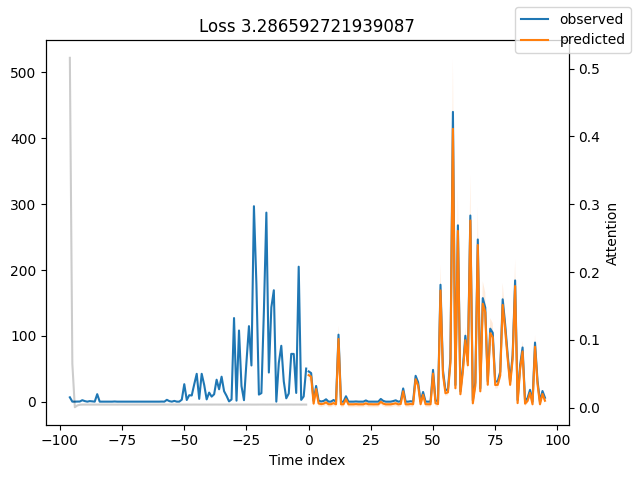

In [17]:
import pandas as pd
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
import matplotlib.pyplot as plt
import glob
import os

print("1. Loading data...")
# Load and prep the data exactly how the model expects it
df = pd.read_parquet("/content/data/master_dataset.parquet")
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df.sort_values(["plant_id", "time"]).reset_index(drop=True)
df["time_of_day"] = (df["time"].dt.hour + df["time"].dt.minute / 60.0) / 24.0
df["day_of_week"] = df["time"].dt.dayofweek / 6.0
df["time_idx"] = df.groupby("plant_id")["time"].transform(lambda s: (s - s.min()).dt.total_seconds() // 900).astype(int)

# Recreate the train/val split
max_idx = df["time_idx"].max()
train_df = df[df["time_idx"] < int(max_idx * 0.8)].copy()
val_df = df[df["time_idx"] >= int(max_idx * 0.8) - 96].copy()

print("2. Rebuilding dataset rules...")
# Tell PyTorch Forecasting how to read the columns
training = TimeSeriesDataSet(
    train_df, time_idx="time_idx", target="generation_mw", group_ids=["plant_id"],
    static_categoricals=["asset_type"],
    categorical_encoders={"asset_type": NaNLabelEncoder(add_nan=True)},
    static_reals=["capacity_mw", "latitude", "longitude"],
    time_varying_known_reals=["ghi", "wind_speed_100m", "temperature_2m", "cloud_cover", "time_of_day", "day_of_week"],
    time_varying_unknown_reals=["generation_mw"],
    max_encoder_length=96, max_prediction_length=96,
    allow_missing_timesteps=True,
    add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
)
validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=True, stop_randomization=True)

print("3. Loading Model Checkpoint...")
ckpt_list = glob.glob("/content/models/checkpoints/*.ckpt")
best_model_path = max(ckpt_list, key=os.path.getctime)
model = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

print("4. Generating Forecast Plot...")
# Predict!
val_dataloader = validation.to_dataloader(train=False, batch_size=32, num_workers=0)
raw_predictions = model.predict(val_dataloader, mode="raw", return_x=True)

# Plot the first item in the batch
plt.figure(figsize=(10, 6))
fig = model.plot_prediction(raw_predictions.x, raw_predictions.output, idx=0, add_loss_to_title=True)
plt.tight_layout()
plt.show()

In [22]:
%%writefile /content/models/conformal.py
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import glob
import os
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
import warnings

warnings.filterwarnings("ignore")

def run_conformal():
    print("1. Loading Data and Creating Splits...")
    df = pd.read_parquet("/content/data/master_dataset.parquet")
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df = df.sort_values(["plant_id", "time"]).reset_index(drop=True)
    df["time_of_day"] = (df["time"].dt.hour + df["time"].dt.minute / 60.0) / 24.0
    df["day_of_week"] = df["time"].dt.dayofweek / 6.0
    df["time_idx"] = df.groupby("plant_id")["time"].transform(lambda s: (s - s.min()).dt.total_seconds() // 900).astype(int)

    # Splitting: Train (80%), Calibration (10%), Test (10%)
    max_idx = df["time_idx"].max()
    train_df = df[df["time_idx"] < int(max_idx * 0.8)].copy()
    cal_df = df[(df["time_idx"] >= int(max_idx * 0.8) - 96) & (df["time_idx"] < int(max_idx * 0.9))].copy()
    test_df = df[df["time_idx"] >= int(max_idx * 0.9) - 96].copy()

    print("2. Rebuilding TimeSeries Rules...")
    training = TimeSeriesDataSet(
        train_df, time_idx="time_idx", target="generation_mw", group_ids=["plant_id"],
        static_categoricals=["asset_type"],
        categorical_encoders={"asset_type": NaNLabelEncoder(add_nan=True)},
        static_reals=["capacity_mw", "latitude", "longitude"],
        time_varying_known_reals=["ghi", "wind_speed_100m", "temperature_2m", "cloud_cover", "time_of_day", "day_of_week"],
        time_varying_unknown_reals=["generation_mw"],
        max_encoder_length=96, max_prediction_length=96,
        allow_missing_timesteps=True, add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
    )

    cal_dataset = TimeSeriesDataSet.from_dataset(training, cal_df, predict=True, stop_randomization=True)
    test_dataset = TimeSeriesDataSet.from_dataset(training, test_df, predict=True, stop_randomization=True)

    print("3. Loading Best Model Checkpoint...")
    best_model_path = max(glob.glob("/content/models/checkpoints/*.ckpt"), key=os.path.getctime)
    model = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

    print("4. Generating Predictions for Calibration Set...")
    cal_dataloader = cal_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)
    cal_preds = model.predict(cal_dataloader, mode="raw", return_x=True)

    # FIX: Move target to CPU
    y_cal_true = cal_preds.x["decoder_target"].cpu()

    # FIX: Move predictions to CPU
    cal_prediction_tensor = cal_preds.output[0].cpu()
    y_cal_low = cal_prediction_tensor[..., 0]  # 10th percentile
    y_cal_high = cal_prediction_tensor[..., 2] # 90th percentile

    print("5. Calculating Conformal Scores (CQR)...")
    # Score = max(lower_bound - actual, actual - upper_bound)
    scores = torch.maximum(y_cal_low - y_cal_true, y_cal_true - y_cal_high)

    # Calculate the 90th percentile of the scores to act as our correction factor
    alpha = 0.1
    n = scores.numel()
    q_val = np.quantile(scores.numpy(), np.ceil((n + 1) * (1 - alpha)) / n)
    print(f"\n✅ Conformal Correction Factor (q_hat): {q_val:.4f} MW")

    print("\n6. Applying Guaranteed Bounds to Test Set...")
    test_dataloader = test_dataset.to_dataloader(train=False, batch_size=32, num_workers=0)
    test_preds = model.predict(test_dataloader, mode="raw", return_x=True)

    idx = 0
    # FIX: Move test targets and predictions to CPU before converting to NumPy
    y_test_true = test_preds.x["decoder_target"][idx].cpu().numpy()
    test_prediction_tensor = test_preds.output[0].cpu()

    y_test_median = test_prediction_tensor[idx, :, 1].numpy()
    y_test_low_raw = test_prediction_tensor[idx, :, 0].numpy()
    y_test_high_raw = test_prediction_tensor[idx, :, 2].numpy()

    # Apply the calibration factor
    y_test_low_cal = np.maximum(y_test_low_raw - q_val, 0) # Floor at 0 MW
    y_test_high_cal = y_test_high_raw + q_val

    print("7. Plotting Final Calibrated Forecast...")
    plt.figure(figsize=(12, 6))
    time_steps = np.arange(len(y_test_true))

    plt.plot(time_steps, y_test_true, label="Actual Generation", color="black", linewidth=2)
    plt.plot(time_steps, y_test_median, label="TFT Median Forecast", color="blue", linestyle="--")
    plt.fill_between(time_steps, y_test_low_cal, y_test_high_cal, color="gray", alpha=0.3, label="90% Conformal Bound")

    plt.title(f"Statistically Guaranteed Forecast (90% Confidence)\nCorrection Factor Applied: ±{q_val:.2f} MW")
    plt.xlabel("Time Steps (15-min intervals)")
    plt.ylabel("Generation (MW)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/models/conformal_forecast.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    run_conformal()

Overwriting /content/models/conformal.py


In [23]:
!python /content/models/conformal.py

1. Loading Data and Creating Splits...
2. Rebuilding TimeSeries Rules...
3. Loading Best Model Checkpoint...
4. Generating Predictions for Calibration Set...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
5. Calculating Conformal Scores (CQR)...

✅ Conformal Correction Factor (q_hat): 1.3076 MW

6. Applying Guaranteed Bounds to Test Set...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try insta